Viral sequences were identified from hybrid and short-read metagenomic assemblies and dereplicated into vOTUs using identical pipelines.

In [1]:
import pandas as pd

df_hybrid = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','votu_len','checkv_quality','checkv_completeness'])
df_shortread = pd.read_csv('../data/hybrid_vs_shortread_comparison/shortread_votu_checkv_quality_summary.tsv', sep='\t').rename(columns={'contig_id': 'votu_id', 'contig_length': 'votu_len', 'completeness': 'checkv_completeness'})[['votu_id','votu_len','checkv_quality','checkv_completeness']]

"median length=**8.4kbp**"

In [2]:
df_shortread.votu_len.median()

np.float64(8393.0)

"short-read–only assemblies rarely generated vOTUs longer than 30kbp (**>10× reduction** relative to long-read–augmented assemblies)"

In [3]:
df_hybrid_30kbp = df_hybrid[df_hybrid['votu_len'] > 30e3]
df_shortread_30kbp = df_shortread[df_shortread['votu_len'] > 30e3]

len(df_hybrid_30kbp)/len(df_shortread_30kbp)

10.691437802907917

"only **258** short-read vOTUs assessed as being high-quality or complete (**>13× reduction**)"

In [4]:
hq_complete = ['High-quality','Complete']

df_shortread.checkv_quality.isin(hq_complete).sum(), df_hybrid.checkv_quality.isin(hq_complete).sum()/df_shortread.checkv_quality.isin(hq_complete).sum()

(np.int64(258), np.float64(13.608527131782946))

### Fig. 1B: KDE plot of length vs. completeness of hybrid and short-read vOTUs

vOTUs with undetermined completeness values were excluded.

In [5]:
df_hybrid1 = df_hybrid[~df_hybrid.checkv_completeness.isnull()].copy()
df_hybrid1['Assembly'] = 'long-read'

df_shortread1 = df_shortread[~df_shortread.checkv_completeness.isnull()].copy()
df_shortread1['Assembly'] = 'short-read'

df_both = pd.concat([df_hybrid1, df_shortread1])

c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


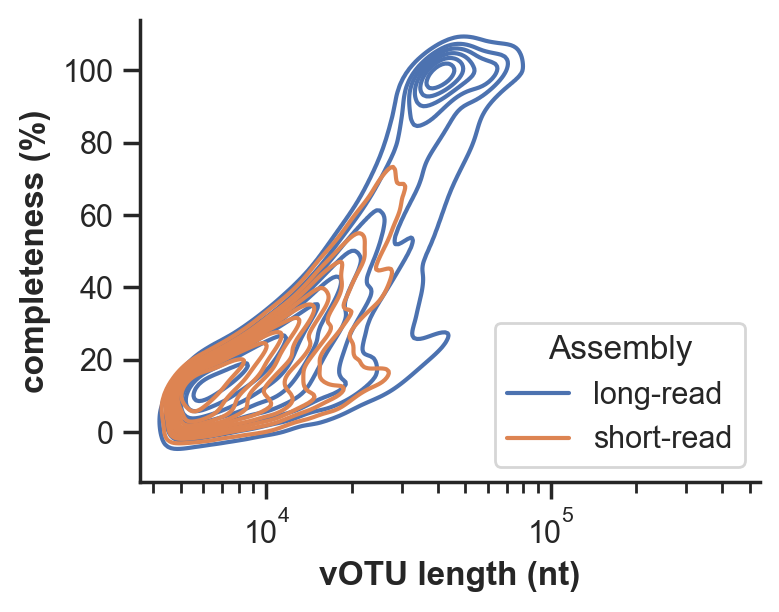

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='ticks')

fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

g = sns.kdeplot(
    data=df_both,
    x='votu_len',
    y='checkv_completeness',
    log_scale=(True, False),
    hue='Assembly',
    bw_adjust=0.8,
    thresh=.1,
    linewidth=0.1
)

sns.move_legend(g, 'lower right')

plt.xlabel('vOTU length (nt)', fontweight='bold')
plt.ylabel('completeness (%)', fontweight='bold')

sns.despine()